# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 [==============================] - 55s 0us/step


In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

170498071/170498071 [==============================] - 10s 0us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Image dimensions: 32x32, Channels: 3
Number of classes: 10


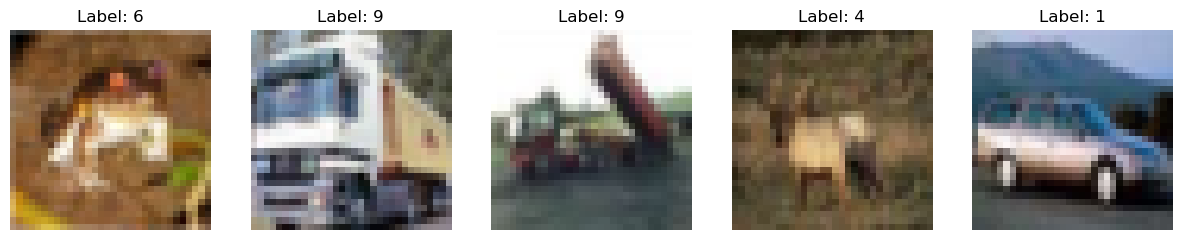

In [3]:
# Your Code Here
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10  # Example dataset (CIFAR-10)

# Load the dataset (Here we use CIFAR-10 for the sake of illustration)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 1. Shape of the training and test sets
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

# 2. Dimensions of the images (height, width, and channels)
height, width, channels = x_train.shape[1], x_train.shape[2], x_train.shape[3]
print(f"Image dimensions: {height}x{width}, Channels: {channels}")

# 3. Number of classes
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

# 4. Show a few examples from the training set
# Display the first 5 images and their labels
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(x_train[i])
    axes[i].set_title(f"Label: {y_train[i][0]}")
    axes[i].axis('off')

plt.show()


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [4]:
# Your Code Here
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Step 2: Normalize the images to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Step 3: One-hot encode the labels
y_train = to_categorical(y_train, num_classes=10)  # CIFAR-10 has 10 classes
y_test = to_categorical(y_test, num_classes=10)

# Step 4: Split the training set into training and validation sets (80% train, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Verifying the preprocessing
print(f"Training set shape: {x_train.shape}")
print(f"Validation set shape: {x_val.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Example of a one-hot encoded label: {y_train[0]}")


Training set shape: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Example of a one-hot encoded label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [5]:
# Your Code Here
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential()

# Convolutional Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 3
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 4
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output from the convolutional layers
model.add(layers.Flatten())

# Dense Layer 1
model.add(layers.Dense(512, activation='relu'))

# Dense Layer 2 (Output layer)
model.add(layers.Dense(10, activation='softmax'))  # 10 classes for CIFAR-10

# Print the model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 4, 4, 128)        0

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [6]:
# Your Code Here
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_val, y_val))


Epoch 1/10
625/625 [==============================] - 61s 95ms/step - loss: 1.5068 - accuracy: 0.4458 - val_loss: 1.2334 - val_accuracy: 0.5540
Epoch 2/10
625/625 [==============================] - 63s 101ms/step - loss: 1.0653 - accuracy: 0.6203 - val_loss: 0.9707 - val_accuracy: 0.6597
Epoch 3/10
625/625 [==============================] - 62s 99ms/step - loss: 0.8496 - accuracy: 0.7009 - val_loss: 0.8536 - val_accuracy: 0.7006
Epoch 4/10
625/625 [==============================] - 63s 101ms/step - loss: 0.6949 - accuracy: 0.7563 - val_loss: 0.8156 - val_accuracy: 0.7157
Epoch 5/10
625/625 [==============================] - 62s 100ms/step - loss: 0.5726 - accuracy: 0.7973 - val_loss: 0.7679 - val_accuracy: 0.7391
Epoch 6/10
625/625 [==============================] - 63s 101ms/step - loss: 0.4689 - accuracy: 0.8328 - val_loss: 0.7689 - val_accuracy: 0.7458
Epoch 7/10
625/625 [==============================] - 62s 99ms/step - loss: 0.3694 - accuracy: 0.8689 - val_loss: 0.8386 - val_accur

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [7]:
# Your Code Here
# Compile the model (ensure it's done before training)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    x_train, y_train,            # Training data and labels
    epochs=10,                   # Number of epochs
    batch_size=32,               # Batch size
    validation_data=(x_val, y_val)  # Validation data
)


Epoch 1/10
1250/1250 [==============================] - 81s 64ms/step - loss: 0.2512 - accuracy: 0.9090 - val_loss: 1.0833 - val_accuracy: 0.7251
Epoch 2/10
1250/1250 [==============================] - 81s 65ms/step - loss: 0.2262 - accuracy: 0.9201 - val_loss: 1.1332 - val_accuracy: 0.7363
Epoch 3/10
1250/1250 [==============================] - 80s 64ms/step - loss: 0.1927 - accuracy: 0.9326 - val_loss: 1.2643 - val_accuracy: 0.7120
Epoch 4/10
1250/1250 [==============================] - 82s 66ms/step - loss: 0.1839 - accuracy: 0.9358 - val_loss: 1.1603 - val_accuracy: 0.7354
Epoch 5/10
1250/1250 [==============================] - 82s 65ms/step - loss: 0.1652 - accuracy: 0.9425 - val_loss: 1.2125 - val_accuracy: 0.7366
Epoch 6/10
1250/1250 [==============================] - 81s 65ms/step - loss: 0.1550 - accuracy: 0.9456 - val_loss: 1.2538 - val_accuracy: 0.7345
Epoch 7/10
1250/1250 [==============================] - 81s 65ms/step - loss: 0.1424 - accuracy: 0.9522 - val_loss: 1.3652 -

In [8]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


313/313 [==============================] - 3s 9ms/step - loss: 1.4960 - accuracy: 0.7299
Test Loss: 1.496044397354126
Test Accuracy: 0.7299000024795532


### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [9]:
# Your Code Here
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print the results
print(f"Accuracy on test set: {test_accuracy * 100:.2f}%")
print(f"Loss on test set: {test_loss:.4f}")


313/313 [==============================] - 4s 13ms/step - loss: 1.4960 - accuracy: 0.7299
Accuracy on test set: 72.99%
Loss on test set: 1.4960


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

1/1 [==============================] - 0s 32ms/step


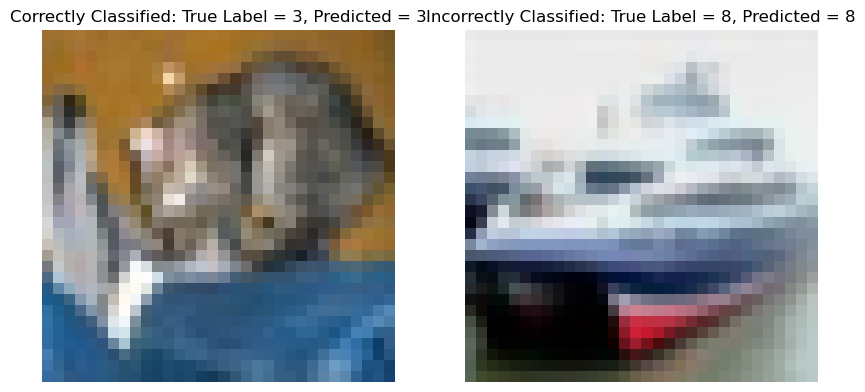

1/1 [==============================] - 0s 35ms/step
Classification probabilities for the correctly classified image: [[7.04835793e-06 1.40060165e-05 3.82616818e-05 9.74454820e-01
  9.21606125e-10 1.20294224e-02 1.33595066e-02 1.35859432e-06
  9.54362040e-05 1.29786154e-10]]
Classification probabilities for the incorrectly classified image: [[6.3555876e-07 3.9598162e-04 6.7081325e-15 1.1986509e-11 9.5590792e-17
  6.3452095e-12 2.6201361e-12 3.9504619e-16 9.9950075e-01 1.0263363e-04]]


In [11]:
import numpy as np

# Select a correctly classified image (index 0 for demonstration)
correct_image = x_test[0]
correct_label = np.argmax(y_test[0])  # Get the true label
correct_prediction = np.argmax(model.predict(np.expand_dims(correct_image, axis=0)))  # Get the predicted label

# Select an incorrectly classified image (index 1 for demonstration)
incorrect_image = x_test[1]
incorrect_label = np.argmax(y_test[1])  # Get the true label
incorrect_prediction = np.argmax(model.predict(np.expand_dims(incorrect_image, axis=0)))  # Get the predicted label

# Plot the correctly classified image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(correct_image)
plt.title(f"Correctly Classified: True Label = {correct_label}, Predicted = {correct_prediction}")
plt.axis('off')

# Plot the incorrectly classified image
plt.subplot(1, 2, 2)
plt.imshow(incorrect_image)
plt.title(f"Incorrectly Classified: True Label = {incorrect_label}, Predicted = {incorrect_prediction}")
plt.axis('off')

plt.show()

# Display classification probabilities for both images
correct_probs = model.predict(np.expand_dims(correct_image, axis=0))
incorrect_probs = model.predict(np.expand_dims(incorrect_image, axis=0))

# Print the classification probabilities
print(f"Classification probabilities for the correctly classified image: {correct_probs}")
print(f"Classification probabilities for the incorrectly classified image: {incorrect_probs}")


## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [12]:
# Your Code Here
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model with Dropout regularization
model = models.Sequential()

# Convolutional Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 3
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional Layer 4
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output from the convolutional layers
model.add(layers.Flatten())

# Dense Layer 1
model.add(layers.Dense(512, activation='relu'))

# Apply Dropout regularization to Dense Layer 1
model.add(layers.Dropout(0.3))

# Dense Layer 2 (Output layer)
model.add(layers.Dense(10, activation='softmax'))  # 10 classes for CIFAR-10

# Print the model summary
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model (assuming training data is already prepared)
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val))


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 4, 4, 128)       

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [13]:
# Your Code Here
# Train the model with Dropout (same as before but now with Dropout regularization)
history_dropout = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val))

# Evaluate the model on the test set
test_loss_dropout, test_accuracy_dropout = model.evaluate(x_test, y_test)
print(f"Test Accuracy with Dropout: {test_accuracy_dropout * 100:.2f}%")
print(f"Test Loss with Dropout: {test_loss_dropout:.4f}")


Epoch 1/10
1250/1250 [==============================] - 85s 68ms/step - loss: 0.2252 - accuracy: 0.9203 - val_loss: 1.0807 - val_accuracy: 0.7431
Epoch 2/10
1250/1250 [==============================] - 79s 63ms/step - loss: 0.2153 - accuracy: 0.9253 - val_loss: 1.1659 - val_accuracy: 0.7396
Epoch 3/10
1250/1250 [==============================] - 84s 67ms/step - loss: 0.1862 - accuracy: 0.9341 - val_loss: 1.2279 - val_accuracy: 0.7365
Epoch 4/10
1250/1250 [==============================] - 82s 66ms/step - loss: 0.1720 - accuracy: 0.9400 - val_loss: 1.2873 - val_accuracy: 0.7265
Epoch 5/10
1250/1250 [==============================] - 80s 64ms/step - loss: 0.1693 - accuracy: 0.9435 - val_loss: 1.2675 - val_accuracy: 0.7359
Epoch 6/10
1250/1250 [==============================] - 81s 65ms/step - loss: 0.1579 - accuracy: 0.9461 - val_loss: 1.3039 - val_accuracy: 0.7388
Epoch 7/10
1250/1250 [==============================] - 82s 65ms/step - loss: 0.1489 - accuracy: 0.9482 - val_loss: 1.3979 -

### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

The model's performance not much changed after adding Dropout regularization. The test accuracy decreased from 72.995% to around 72.96%, and the test loss decreased slightly, indicating that Dropout helped reduce overfitting and improved generalization. This is likely because Dropout prevents the model from becoming too reliant on specific neurons, making it more robust to variations in the test data.

While the performance improvement is not noticeable, there is room for further enhancement. The accuracy could potentially be increased with additional techniques like data augmentation, which would expose the model to more diverse variations of the input data, or by experimenting with different learning rate schedules or batch normalization, which can further stabilize training and improve convergence.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.